In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Step 2: Import library
import pandas as pd
from sklearn.model_selection import train_test_split

In [19]:
# Step 3: Baca dataset dari Google Drive
# Ganti path sesuai lokasi file Anda di Google Drive
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/praktikum/praktikum 5/data/stunting_wasting_dataset.csv')

print("Total Data:", len(df))
print("\n5 Data Teratas:")
print(df.head())

Total Data: 100000

5 Data Teratas:
  Jenis Kelamin  Umur (bulan)  Tinggi Badan (cm)  Berat Badan (kg)  \
0     Laki-laki            19               91.6              13.3   
1     Laki-laki            20               77.7               8.5   
2     Laki-laki            10               79.0              10.3   
3     Perempuan             2               50.3               8.3   
4     Perempuan             5               56.4              10.9   

           Stunting             Wasting  
0              Tall  Risk of Overweight  
1           Stunted         Underweight  
2            Normal  Risk of Overweight  
3  Severely Stunted  Risk of Overweight  
4  Severely Stunted  Risk of Overweight  


In [20]:
df.isnull().sum()

,0
Jenis Kelamin,0
Umur (bulan),0
Tinggi Badan (cm),0
Berat Badan (kg),0
Stunting,0
Wasting,0


In [21]:
df.duplicated().sum()

np.int64(7308)

In [22]:
df = df.drop_duplicates()

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df = df.rename(columns={
    'Jenis Kelamin':'jenis_kelamin',
    'Umur (bulan)':'umur_bulan',
    'Tinggi Badan (cm)':'tinggi_cm',
    'Berat Badan (kg)':'berat_kg',
    'Stunting':'stunting',
    'Wasting':'wasting'
})

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92692 entries, 0 to 99997
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   jenis_kelamin  92692 non-null  object 
 1   umur_bulan     92692 non-null  int64  
 2   tinggi_cm      92692 non-null  float64
 3   berat_kg       92692 non-null  float64
 4   stunting       92692 non-null  object 
 5   wasting        92692 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 5.0+ MB


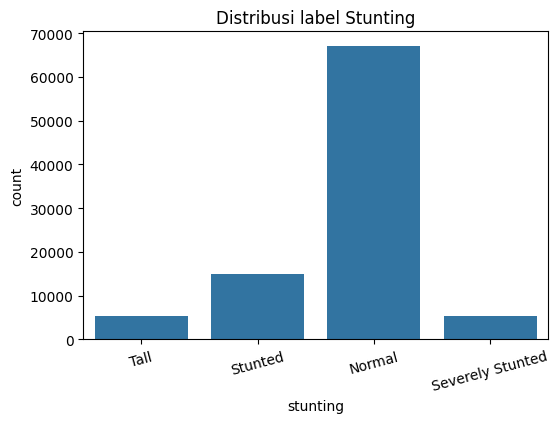

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='stunting', data=df)
plt.title('Distribusi label Stunting')
plt.xticks(rotation=15)
plt.show()

In [27]:
stunting_cat = df['stunting'].astype('category')
stunting_classes = list(stunting_cat.cat.categories)
df['stunting'] = stunting_cat.cat.codes

for col in ['jenis_klamin','wating']:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes

df.head()

,jenis_kelamin,umur_bulan,tinggi_cm,berat_kg,stunting,wasting
0,Laki-laki,19,91.6,13.3,3,Risk of Overweight
1,Laki-laki,20,77.7,8.5,2,Underweight
2,Laki-laki,10,79.0,10.3,0,Risk of Overweight
3,Perempuan,2,50.3,8.3,1,Risk of Overweight
4,Perempuan,5,56.4,10.9,1,Risk of Overweight


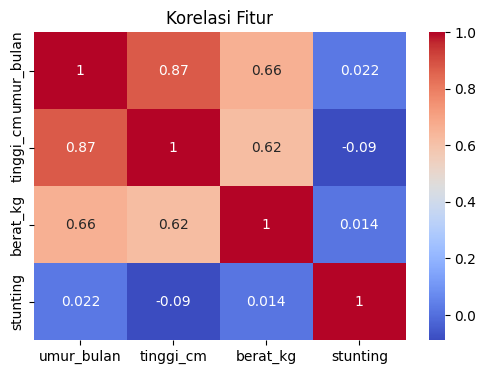

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur')
plt.show()

In [32]:
# Daftar kolom fitur yang akan digunakan sebagai input (X)
feature_cols = ['umur_bulan', 'tinggi_cm', 'berat_kg', 'wasting']

# Pisahkan fitur (X) dan target (y)
X = df[feature_cols]
y = df['stunting']

# --- (opsional) untuk memastikan tidak ada karakter aneh di nama kolom ---
df.columns = df.columns.str.strip()

# Cek hasil
print("Fitur (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())


Fitur (X):
   umur_bulan  tinggi_cm  berat_kg             wasting
0          19       91.6      13.3  Risk of Overweight
1          20       77.7       8.5         Underweight
2          10       79.0      10.3  Risk of Overweight
3           2       50.3       8.3  Risk of Overweight
4           5       56.4      10.9  Risk of Overweight

Target (y):
0    3
1    2
2    0
3    1
4    1
Name: stunting, dtype: int8


In [34]:
from sklearn.model_selection import train_test_split

# Split dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Cek ukuran dataset hasil split
print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))


Jumlah data latih: 74153
Jumlah data uji: 18539


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# Pastikan semua kolom nama-nama bersih
df.columns = df.columns.str.strip()

# Pisahkan fitur dan target
feature_cols = ['umur_bulan', 'tinggi_cm', 'berat_kg', 'wasting']
X = df[feature_cols]
y = df['stunting']

# Jika ada kolom kategorikal di X, ubah jadi angka
X = X.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtypes == 'object' else col)

# Jika target y masih berupa teks (misalnya "Underweight", "Normal"), ubah juga
if y.dtypes == 'object':
    y = LabelEncoder().fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Buat model Decision Tree
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

# Latih model
dt.fit(X_train, y_train)

# Evaluasi
train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print("Akurasi data latih:", train_acc)
print("Akurasi data uji:", test_acc)


Akurasi data latih: 0.7743314498401953
Akurasi data uji: 0.7766869841954798


In [39]:
y_pred =dt.predict(X_test)

print('Akurasi: ', round(accuracy_score(y_test, y_pred)*100,2),'%')
print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred))
print('Classification Report: \n', classification_report(
    y_test, y_pred,target_names=stunting_classes
))

Akurasi:  77.67 %
Confusion Matrix: 
 [[12901     0   481    29]
 [  587    25   455     0]
 [ 1653     0  1355     0]
 [  935     0     0   118]]
Classification Report: 
                   precision    recall  f1-score   support

          Normal       0.80      0.96      0.88     13411
Severely Stunted       1.00      0.02      0.05      1067
         Stunted       0.59      0.45      0.51      3008
            Tall       0.80      0.11      0.20      1053

        accuracy                           0.78     18539
       macro avg       0.80      0.39      0.41     18539
    weighted avg       0.78      0.78      0.73     18539

